In [1]:
print("Stock Market Price Prediction Model")

Stock Market Price Prediction Model


In [2]:
import yfinance as yf 
import requests 
bse = yf.Ticker("^BSESN")


#getting historical market data 
stock_ds= bse.history(start= "2001-01-01",end = "2025-12-31")
stock_ds= stock_ds.to_csv("stock_data.csv")

In [3]:
import pandas as pd 
import numpy as np 

stock_ds= pd.read_csv("stock_data.csv", parse_dates= ['Date'] , index_col=['Date'])



In [4]:
stock_ds.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2001-01-02 00:00:00+05:30,3953.219971,4028.570068,3929.370117,4018.879883,0,0.0,0.0
2001-01-03 00:00:00+05:30,3977.580078,4067.659912,3977.580078,4060.020020,0,0.0,0.0
2001-01-04 00:00:00+05:30,4180.970215,4180.970215,4109.549805,4115.370117,0,0.0,0.0
2001-01-05 00:00:00+05:30,4116.339844,4195.009766,4115.350098,4183.729980,0,0.0,0.0
2001-01-08 00:00:00+05:30,4164.759766,4206.720215,4101.529785,4120.430176,0,0.0,0.0


In [5]:
stock_ds.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-12-23 00:00:00+05:30,85690.101562,85704.929688,85342.992188,85524.843750,6100,0.0,0.0
2025-12-24 00:00:00+05:30,85533.109375,85738.179688,85342.187500,85408.703125,8400,0.0,0.0
2025-12-26 00:00:00+05:30,85225.281250,85378.507812,84937.820312,85041.453125,4800,0.0,0.0
2025-12-29 00:00:00+05:30,85004.750000,85250.000000,84637.859375,84695.539062,53300,0.0,0.0
2025-12-30 00:00:00+05:30,84600.992188,84806.992188,84470.937500,84675.078125,6900,0.0,0.0


In [6]:
stock_ds.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6159 entries, 2001-01-02 00:00:00+05:30 to 2025-12-30 00:00:00+05:30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          6159 non-null   float64
 1   High          6159 non-null   float64
 2   Low           6159 non-null   float64
 3   Close         6159 non-null   float64
 4   Volume        6159 non-null   int64  
 5   Dividends     6159 non-null   float64
 6   Stock Splits  6159 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 384.9 KB


In [7]:
news= pd.read_csv("india-news-headlines.csv", parse_dates=['publish_date'], index_col=['publish_date'])

In [8]:
news.head()

,headline_category,headline_text
publish_date,,
2001-01-02,unknown,Status quo will not be disturbed at Ayodhya; s...
2001-01-02,unknown,Fissures in Hurriyat over Pak visit
2001-01-02,unknown,America's unwanted heading for India?
2001-01-02,unknown,For bigwigs; it is destination Goa
2001-01-02,unknown,Extra buses to clear tourist traffic


In [9]:
news.tail()

,headline_category,headline_text
publish_date,,
2023-06-30,city.goa,10 PIs move HC over thwarted seniority
2023-06-30,city.goa,Govt notifies award in memory of Parrikar for ...
2023-06-30,city.goa,After youth's death; PWD installs crash barrie...
2023-06-30,city.goa,Authorities not acting against CRZ violations
2023-06-30,city.goa,Technicians to hold trial run of mini-EVs in P...


In [10]:
stock_ds.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,6159.000000,6159.000000,6159.000000,6159.000000,6.159000e+03,6159.0,6159.0
mean,28225.656936,28376.047797,28033.591279,28204.435029,6.645751e+04,0.0,0.0
std,22269.773749,22353.952475,22166.035677,22261.552025,9.540956e+05,0.0,0.0
min,2621.889893,2682.590088,2594.870117,2600.120117,0.000000e+00,0.0,0.0
25%,11961.214844,12094.455078,11824.854980,11925.930176,8.400000e+03,0.0,0.0
50%,20066.939453,20190.130859,19925.759766,20034.480469,1.260000e+04,0.0,0.0
75%,37989.394531,38140.015625,37721.275391,37904.865234,1.920000e+04,0.0,0.0
max,86065.921875,86159.023438,85577.820312,85836.117188,3.181510e+07,0.0,0.0


In [11]:
stock_ds.drop_duplicates()
stock_ds= stock_ds.loc[:, (stock_ds !=0).any(axis=0)]

In [12]:
stock_ds.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6159 entries, 2001-01-02 00:00:00+05:30 to 2025-12-30 00:00:00+05:30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6159 non-null   float64
 1   High    6159 non-null   float64
 2   Low     6159 non-null   float64
 3   Close   6159 non-null   float64
 4   Volume  6159 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 288.7 KB


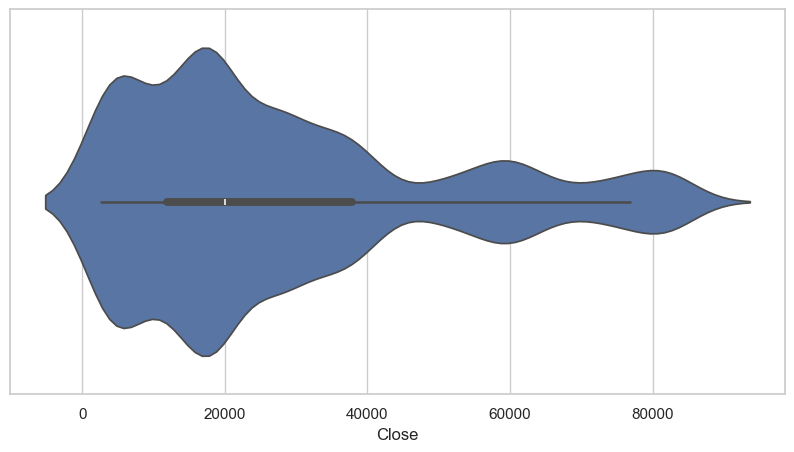

In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid')
plt.figure(figsize=(10,5))
ax=sns.violinplot(x='Close', data=stock_ds, orient="h")

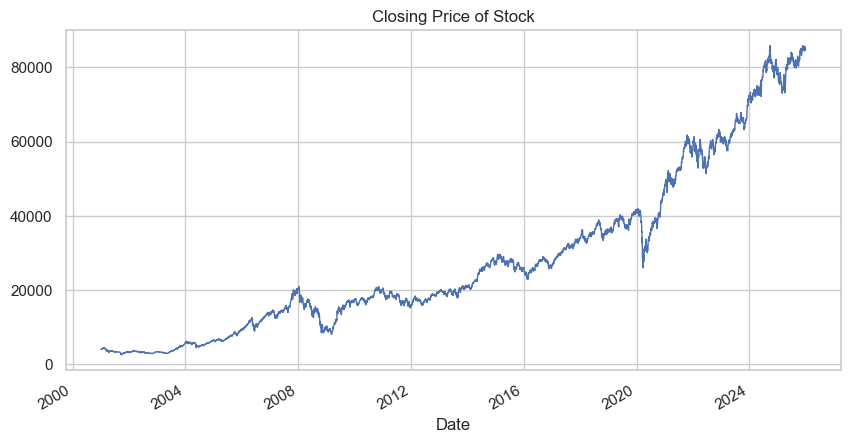

In [14]:
stock_ds.plot(
    y="Close",
    title="Closing Price of Stock",
    grid=True,
    legend=False,
    linewidth=1,
    figsize=(10, 5)
)
plt.show()

In [15]:
stock_ds["Day_Percent_Change"]= stock_ds["Close"].pct_change().fillna(value=0)*100
stock_ds.head()

,Open,High,Low,Close,Volume,Day_Percent_Change
Date,,,,,,
2001-01-02 00:00:00+05:30,3953.219971,4028.570068,3929.370117,4018.879883,0,0.000000
2001-01-03 00:00:00+05:30,3977.580078,4067.659912,3977.580078,4060.020020,0,1.023672
2001-01-04 00:00:00+05:30,4180.970215,4180.970215,4109.549805,4115.370117,0,1.363296
2001-01-05 00:00:00+05:30,4116.339844,4195.009766,4115.350098,4183.729980,0,1.661087
2001-01-08 00:00:00+05:30,4164.759766,4206.720215,4101.529785,4120.430176,0,-1.512999


In [16]:
stock_ds.index

DatetimeIndex(['2001-01-02 00:00:00+05:30', '2001-01-03 00:00:00+05:30',
               '2001-01-04 00:00:00+05:30', '2001-01-05 00:00:00+05:30',
               '2001-01-08 00:00:00+05:30', '2001-01-09 00:00:00+05:30',
               '2001-01-10 00:00:00+05:30', '2001-01-11 00:00:00+05:30',
               '2001-01-12 00:00:00+05:30', '2001-01-15 00:00:00+05:30',
               ...
               '2025-12-16 00:00:00+05:30', '2025-12-17 00:00:00+05:30',
               '2025-12-18 00:00:00+05:30', '2025-12-19 00:00:00+05:30',
               '2025-12-22 00:00:00+05:30', '2025-12-23 00:00:00+05:30',
               '2025-12-24 00:00:00+05:30', '2025-12-26 00:00:00+05:30',
               '2025-12-29 00:00:00+05:30', '2025-12-30 00:00:00+05:30'],
              dtype='datetime64[ns, UTC+05:30]', name='Date', length=6159, freq=None)

daily volume and day percentage change


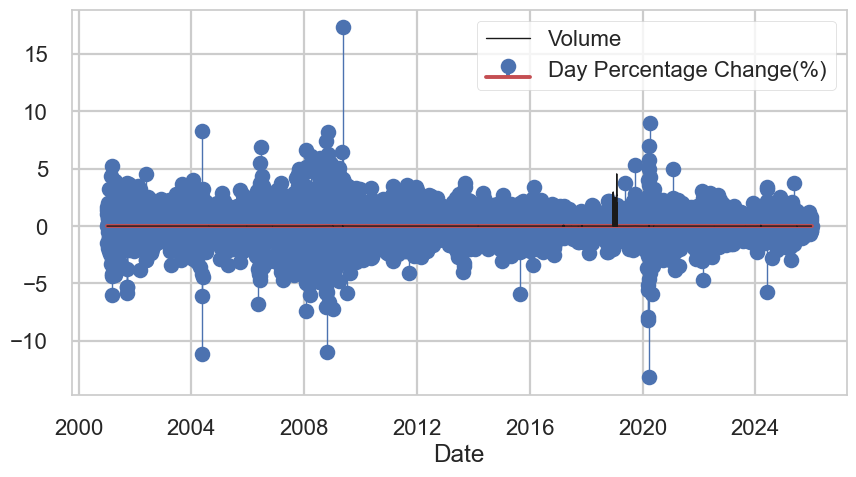

In [17]:
print("daily volume and day percentage change")

with plt.style.context(plt.style.available[23]):
    plt.figure(figsize=(10,5))
    markerline, stemlines,baseline= plt.stem(stock_ds.index, stock_ds.Day_Percent_Change, label="Day Percentage Change(%)") 
    plt.setp(stemlines,'linewidth',1)
    plt.plot(stock_ds.index, stock_ds["Volume"].values/7000000, color='k', linewidth=1, label="Volume")
    plt.xlabel("Date")
    plt.legend()
    plt.show()

Rolling Average


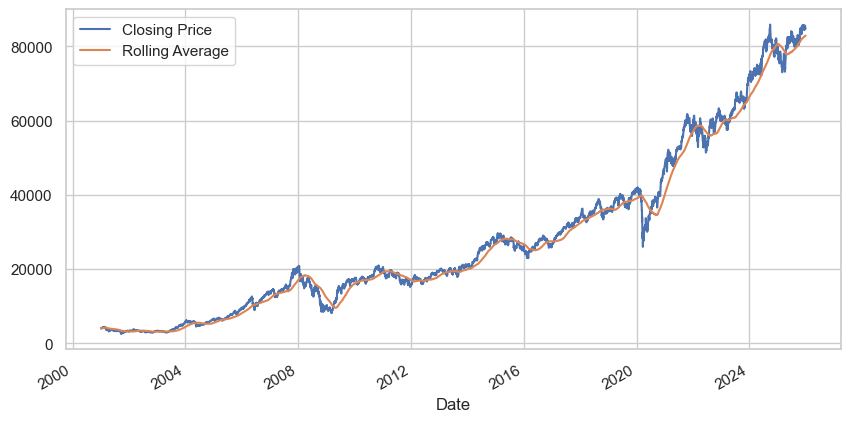

In [18]:
print("Rolling Average")

rolling= stock_ds.Close.rolling('200D').mean()
plt.figure(figsize=(10,5))

stock_ds.Close.plot()
rolling.plot()
plt.legend(["Closing Price", "Rolling Average"])

In [19]:
print("Moving Average Convergence Divergence (MACD)")

from sklearn.metrics import mean_absolute_error
def plotMovingAverage(series,window, plot_intervals=False, scale=1.96, plot_anomalies=False):
    """
    series: dataframe with timeseries
    window: rolling window size
    plot_intervals: show confidence intervals
    scale: float, the width of the confidence intervals
    plot_anomalies: show anomalies
    """
    
    #rolling mean 
    rolling_mean= series.rolling(window=window).mean()

    #plot original series and rolling mean 
    plt.figure(figsize=(15,5))
    plt.title("Moving Average\n window size = {}".format(window))
    plt.plot(rolling_mean, "g", label="Rolling Mean Trend")
    
    #plot confidence intervals for smoothed values
    if plot_intervals:
        mae= mean_absolute_error(series[window:], rolling_mean[window:])
        deviation= np.std(series[window:] - rolling_mean[window:])
        lower_bond= rolling_mean - (mae + scale*deviation)
        upper_bond= rolling_mean + (mae + scale*deviation)
        plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
        plt.plot(lower_bond, "r--")
        
        #plot anomalies
        if plot_anomalies:
            anomalies= pd.DataFrame(index=series.index, columns=series.columns)
            anomalies[series<lower_bond]= series[series<lower_bond]
            anomalies[series>upper_bond]= series[series>upper_bond]
            plt.plot(anomalies, "ro", markersize=10)
    plt.plot(series[window:], label="Actual Values")
    plt.legend(loc="upper left")
    plt.grid(True)        

Moving Average Convergence Divergence (MACD)


d:\Project 2026\Stock_Price_Prediction\.venv\lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


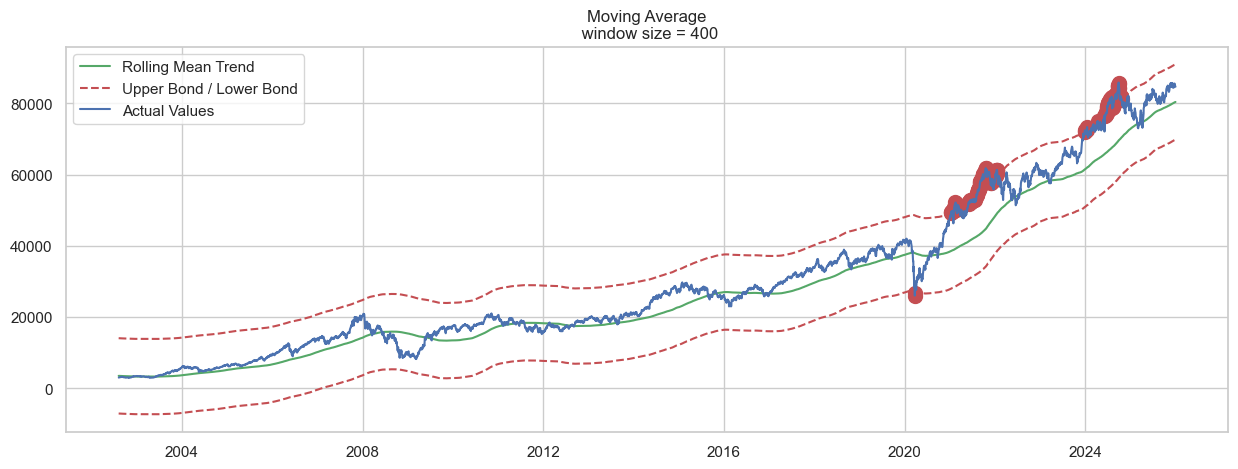

In [20]:
plotMovingAverage(stock_ds[["Close"]], 400, plot_intervals=True,scale=1.96, plot_anomalies=True)

In [21]:
from statsmodels.tsa.stattools import adfuller
def check_stationarity(series):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]}')
    print(f'n_lags: {result[1]}')
    print(f'p-value: {result[1]}')
    for key, value in result[4].items():
        print('Critial Values:')
        print(f'   {key}, {value}')

    print("================================================================")
    if result[0]>.05: 
        print("The series is not stationary")
    else:
        print("The series is stationary")     

check_stationarity(stock_ds["Close"])           

ADF Statistic: 1.6682385731762162
n_lags: 0.9980485185426542
p-value: 0.9980485185426542
Critial Values:
   1%, -3.4314182630857224
Critial Values:
   5%, -2.8620120758402714
Critial Values:
   10%, -2.5670212832604724
The series is not stationary


In [22]:
stock_ds['Close_stationary']= stock_ds['Close'].diff().dropna()
stock_ds= stock_ds[stock_ds['Close_stationary'].notnull()]
stock_ds.head()

,Open,High,Low,Close,Volume,Day_Percent_Change,Close_stationary
Date,,,,,,,
2001-01-03 00:00:00+05:30,3977.580078,4067.659912,3977.580078,4060.020020,0,1.023672,41.140137
2001-01-04 00:00:00+05:30,4180.970215,4180.970215,4109.549805,4115.370117,0,1.363296,55.350098
2001-01-05 00:00:00+05:30,4116.339844,4195.009766,4115.350098,4183.729980,0,1.661087,68.359863
2001-01-08 00:00:00+05:30,4164.759766,4206.720215,4101.529785,4120.430176,0,-1.512999,-63.299805
2001-01-09 00:00:00+05:30,4114.740234,4166.839844,4101.009766,4125.310059,0,0.118431,4.879883


In [23]:
#cheaking stationarity of the new series 
check_stationarity(stock_ds["Close_stationary"])

ADF Statistic: -13.746893146540287
n_lags: 1.0683902372981275e-25
p-value: 1.0683902372981275e-25
Critial Values:
   1%, -3.4314182630857224
Critial Values:
   5%, -2.8620120758402714
Critial Values:
   10%, -2.5670212832604724
The series is stationary


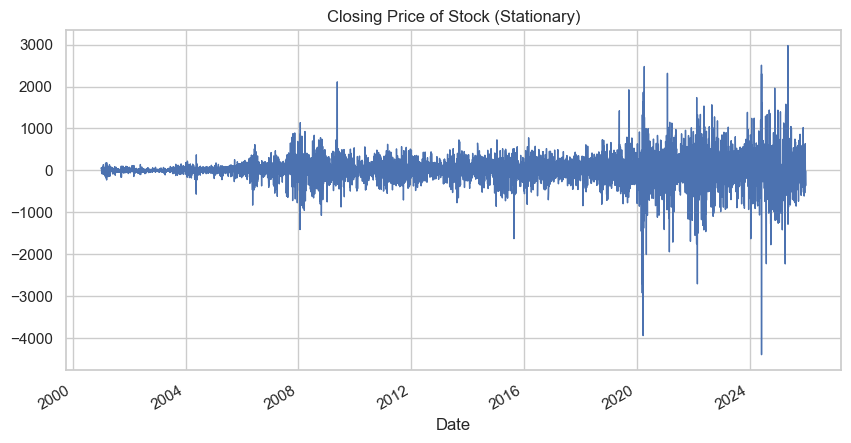

In [24]:
stock_ds.plot(y="Close_stationary", title="Closing Price of Stock (Stationary)", grid=True, legend=False, linewidth=1, figsize=(10, 5))
plt.show()

In [25]:
#sentiment analysis of the news headlines

news.index.name= 'Date'
news.head()

,headline_category,headline_text
Date,,
2001-01-02,unknown,Status quo will not be disturbed at Ayodhya; s...
2001-01-02,unknown,Fissures in Hurriyat over Pak visit
2001-01-02,unknown,America's unwanted heading for India?
2001-01-02,unknown,For bigwigs; it is destination Goa
2001-01-02,unknown,Extra buses to clear tourist traffic


In [26]:
news.drop(columns='headline_category', inplace=True)
news.head()


,headline_text
Date,
2001-01-02,Status quo will not be disturbed at Ayodhya; s...
2001-01-02,Fissures in Hurriyat over Pak visit
2001-01-02,America's unwanted heading for India?
2001-01-02,For bigwigs; it is destination Goa
2001-01-02,Extra buses to clear tourist traffic


In [27]:
news['Polarity']= ""
news['Subjectivity']=''
news.head()

,headline_text,Polarity,Subjectivity
Date,,,
2001-01-02,Status quo will not be disturbed at Ayodhya; s...,,
2001-01-02,Fissures in Hurriyat over Pak visit,,
2001-01-02,America's unwanted heading for India?,,
2001-01-02,For bigwigs; it is destination Goa,,
2001-01-02,Extra buses to clear tourist traffic,,


In [28]:
#checking the huge news data by year 

news_2001= news.loc['2001']
news_2002= news.loc['2002']
news_2003= news.loc['2003']
news_2004= news.loc['2004']
news_2005= news.loc['2005']
news_2006= news.loc['2006']
news_2007= news.loc['2007']
news_2008= news.loc['2008']
news_2009= news.loc['2009']
news_2010= news.loc['2010']
news_2011= news.loc['2011']
news_2012= news.loc['2012']
news_2013= news.loc['2013']
news_2014= news.loc['2014']
news_2015= news.loc['2015']
news_2016= news.loc['2016']
news_2017= news.loc['2017']
news_2018= news.loc['2018']
news_2019= news.loc['2019']
news_2020= news.loc['2020']
news_2021= news.loc['2021']
news_2022= news.loc['2022']
news_2023= news.loc['2023']

In [29]:
from textblob import TextBlob
def sentiment(text): 
    try: 
        return TextBlob(text).sentiment
    except: 
        return None

In [30]:
news_2001['Polarity'] = news_2001['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2002['Polarity'] = news_2002['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2003['Polarity'] = news_2003['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2004['Polarity'] = news_2004['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2005['Polarity'] = news_2005['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2006['Polarity'] = news_2006['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2007['Polarity'] = news_2007['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2008['Polarity'] = news_2008['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2009['Polarity'] = news_2009['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2010['Polarity'] = news_2010['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2011['Polarity'] = news_2011['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2012['Polarity'] = news_2012['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2013['Polarity'] = news_2013['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2014['Polarity'] = news_2014['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2015['Polarity'] = news_2015['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2016['Polarity'] = news_2016['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2017['Polarity'] = news_2017['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2018['Polarity'] = news_2018['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2019['Polarity'] = news_2019['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2020['Polarity'] = news_2020['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2021['Polarity'] = news_2021['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2022['Polarity'] = news_2022['headline_text'].apply(sentiment).apply(lambda x: x[0])
news_2023['Polarity'] = news_2023['headline_text'].apply(sentiment).apply(lambda x: x[0])

C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\1279160565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_2001['Polarity'] = news_2001['headline_text'].apply(sentiment).apply(lambda x: x[0])
C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\1279160565.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_2002['Polarity'] = news_2002['headline_text'].apply(sentiment).apply(lambda x: x[0])
C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\1279160565.py:3: SettingWithCopyWarning: 
A value is trying

In [31]:
news_2001['Subjectivity'] = news_2001['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2002['Subjectivity'] = news_2002['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2003['Subjectivity'] = news_2003['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2004['Subjectivity'] = news_2004['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2005['Subjectivity'] = news_2005['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2006['Subjectivity'] = news_2006['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2007['Subjectivity'] = news_2007['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2008['Subjectivity'] = news_2008['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2009['Subjectivity'] = news_2009['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2010['Subjectivity'] = news_2010['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2011['Subjectivity'] = news_2011['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2012['Subjectivity'] = news_2012['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2013['Subjectivity'] = news_2013['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2014['Subjectivity'] = news_2014['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2015['Subjectivity'] = news_2015['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2016['Subjectivity'] = news_2016['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2017['Subjectivity'] = news_2017['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2018['Subjectivity'] = news_2018['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2019['Subjectivity'] = news_2019['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2020['Subjectivity'] = news_2020['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2021['Subjectivity'] = news_2021['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2022['Subjectivity'] = news_2022['headline_text'].apply(sentiment).apply(lambda x: x[1])
news_2023['Subjectivity'] = news_2023['headline_text'].apply(sentiment).apply(lambda x: x[1])

C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\2762563776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_2001['Subjectivity'] = news_2001['headline_text'].apply(sentiment).apply(lambda x: x[1])
C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\2762563776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_2002['Subjectivity'] = news_2002['headline_text'].apply(sentiment).apply(lambda x: x[1])
C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\2762563776.py:3: SettingWithCopyWarning: 
A value i

In [32]:
news_2023.head()

,headline_text,Polarity,Subjectivity
Date,,,
2023-01-01,happy new year 2023 memes messages wishes 10 f...,0.287121,0.634848
2023-01-01,happy new year quotes wishes and messages to s...,0.468182,0.727273
2023-01-01,Today's Panchang; 1 January 2023: Auspicious T...,0.400000,1.000000
2023-01-01,Today's Panchang; 1 January 2023: Auspicious T...,0.400000,1.000000
2023-01-01,Aries Today's Rashifal - 1 January 2023: Your ...,0.600000,1.000000


In [33]:
news_merged= pd.concat([news_2001, news_2002, news_2003, news_2004, news_2005, news_2006, news_2007, news_2008, news_2009, news_2010, news_2011, news_2012, news_2013, news_2014, news_2015, news_2016, news_2017, news_2018, news_2019, news_2020, news_2021, news_2022, news_2023])

In [34]:
news_merged.tail()

,headline_text,Polarity,Subjectivity
Date,,,
2023-06-30,10 PIs move HC over thwarted seniority,0.0,0.0
2023-06-30,Govt notifies award in memory of Parrikar for ...,0.1,0.4
2023-06-30,After youth's death; PWD installs crash barrie...,0.0,0.0
2023-06-30,Authorities not acting against CRZ violations,0.0,0.0
2023-06-30,Technicians to hold trial run of mini-EVs in P...,0.0,0.0


In [35]:
news_merged['headline_text']= news_merged['headline_text'].astype(str)
news_merged = news_merged.drop_duplicates(subset = ['headline_text'], keep= 'last', inplace=False)
news_merged.head()
news_merged.tail()

,headline_text,Polarity,Subjectivity
Date,,,
2023-06-30,10 PIs move HC over thwarted seniority,0.0,0.0
2023-06-30,Govt notifies award in memory of Parrikar for ...,0.1,0.4
2023-06-30,After youth's death; PWD installs crash barrie...,0.0,0.0
2023-06-30,Authorities not acting against CRZ violations,0.0,0.0
2023-06-30,Technicians to hold trial run of mini-EVs in P...,0.0,0.0


In [36]:
news_merged= news_merged.drop(columns= 'headline_text')
news_merged.head()

,Polarity,Subjectivity
Date,,
2001-01-02,0.00,0.000000
2001-01-02,0.00,0.000000
2001-01-02,0.00,0.000000
2001-01-02,0.05,0.241667
2001-01-02,0.00,0.000000


In [37]:
news_merged.to_csv("news_merged.csv", index=False)

In [38]:
news_merged = news_merged.groupby(['Date']).mean()

In [39]:
print('Merging stock price and news sentiment data')

Merging stock price and news sentiment data


In [40]:
news_merged.index = news_merged.index.tz_localize(None)
stock_ds.index = stock_ds.index.tz_localize(None)
df= pd.merge(stock_ds,news_merged, how='inner', left_index=True, right_index=True)
df.to_csv('stock_news.csv')


In [41]:
print('preproccsing')

preproccsing


In [42]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from sklearn.model_selection import train_test_split

df= pd.read_csv('stock_news.csv', parse_dates=['Date'], index_col=['Date'])
df.head(10)

,Open,High,Low,Close,Volume,Day_Percent_Change,Close_stationary,Polarity,Subjectivity
Date,,,,,,,,,
2001-01-03,3977.580078,4067.659912,3977.580078,4060.020020,0,1.023672,41.140137,0.011280,0.061890
2001-01-04,4180.970215,4180.970215,4109.549805,4115.370117,0,1.363296,55.350098,0.028047,0.144565
2001-01-05,4116.339844,4195.009766,4115.350098,4183.729980,0,1.661087,68.359863,0.140521,0.231354
2001-01-08,4164.759766,4206.720215,4101.529785,4120.430176,0,-1.512999,-63.299805,0.013088,0.108064
2001-01-09,4114.740234,4166.839844,4101.009766,4125.310059,0,0.118431,4.879883,0.012452,0.169859
2001-01-10,4151.580078,4155.859863,4035.439941,4047.639893,0,-1.882772,-77.670166,0.000000,0.000000
2001-01-23,4277.830078,4321.750000,4272.870117,4296.689941,0,0.693211,29.580078,0.028388,0.091143
2001-01-24,4320.509766,4339.410156,4295.709961,4326.419922,0,0.691928,29.729980,0.034815,0.100741
2001-01-25,4327.839844,4341.330078,4273.700195,4330.220215,0,0.087839,3.800293,0.000430,0.203115


In [43]:
print('Model 1: ARIMA ')

Model 1: ARIMA 


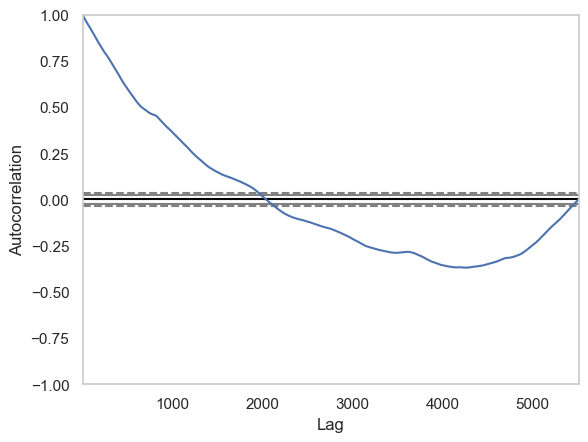

In [44]:
#autocorrelation plot 
autocorrelation_plot(df['Close'])
plt.show()

predicted=25789.172503, expected=25864.470703
predicted=25880.213510, expected=25482.519531
predicted=25454.314172, expected=25841.919922
predicted=25883.238895, expected=25868.490234
predicted=25864.425223, expected=25819.339844
predicted=25806.255944, expected=25775.740234
predicted=25779.904295, expected=25958.630859
predicted=25966.203103, expected=26128.199219
predicted=26137.787050, expected=26145.669922
predicted=26139.140933, expected=26169.410156
predicted=26166.074045, expected=26117.849609
predicted=26105.643981, expected=25886.619141
predicted=25863.134878, expected=25638.109375
predicted=25624.637669, expected=25530.109375
predicted=25534.139511, expected=25310.330078
predicted=25304.788522, expected=25036.050781
predicted=25030.639114, expected=25252.320312
predicted=25292.529073, expected=25044.429688
predicted=25032.285290, expected=25150.349609
predicted=25168.899825, expected=25320.439453
predicted=25342.427658, expected=25494.369141
predicted=25497.282022, expected=2

Text(0.5, 1.0, 'Original vs Predicted Stock Price ')

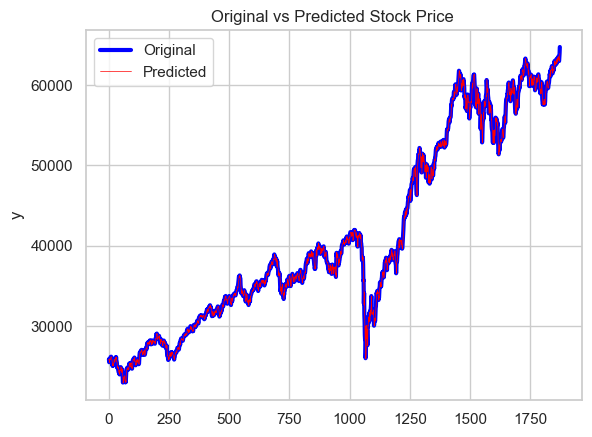

In [45]:
#stats model 
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt 

#split into train and test sets 
X= df['Close'].values
size= int(len(X)*0.66)
train, test= X[0:size], X[size:len(X)]
history = [x for x in train]
predictions= list()

#walk-forward validation 
for t in range(len(test)): 
    model= ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output= model_fit.forecast()
    yhat= output[0]
    predictions.append(yhat)
    obs= test[t]
    history.append(obs)
    print('predicted=%f, expected=%f' % (yhat, obs))
#evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)

#plot forecasts against actual outcomes
plt.plot(test,color = 'blue' , linewidth=3 , label= 'Original')
plt.plot(predictions, color = 'red', linewidth=0.5, label='Predicted')
plt.legend()
plt.ylabel('y')
plt.xticks(x=df.index)
plt.title('Original vs Predicted Stock Price ')


In [46]:
print('Model 2: LSTM')

Model 2: LSTM


In [47]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf 
import os 

In [48]:
import pandas as pd 

In [49]:
#spliting the data into train and test sets
train_df, test_df= df[1:3668],df[3668:len(df)]

In [50]:
#scalling the values 
train= train_df 
scalers= {}
for i in train_df.columns: 
    scaler= MinMaxScaler(feature_range=(-1,1))
    s_s=scaler.fit_transform(train[i].values.reshape(-1,1))
    s_s=np.reshape(s_s,len(s_s))
    scalers['scaler_'+i]=scaler
    train[i]= s_s
test= test_df
for i in test_df.columns:
    scaler= scalers['scaler_'+i]
    s_s=scaler.transform(test[i].values.reshape(-1,1))
    s_s=np.reshape(s_s,len(s_s))
    scalers['scaler'+i]=scaler
    test[i]= s_s    

C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\4121296376.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[i]= s_s
C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\4121296376.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[i]= s_s
C:\Users\fist7\AppData\Local\Temp\ipykernel_3104\4121296376.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [51]:
#converting the series to samples 
def split_series(series,n_past,n_future):
    """
    series: dataframe with timeseries
    n_past: number of past days used for prediction
    n_future: number of days to predict in the future
    """
    X,y= list(),list()
    for window_start in range(len(series)): 
        past_end= window_start+n_past
        future_end= past_end+n_future
        if future_end> len(series):
            break
        #slicing the past and the future parts of the window 
        past,future = series[window_start:past_end,:], series[past_end:future_end,:]
        X.append(past)
        y.append(future)
    return np.array(X), np.array(y)

In [52]:
n_past=30
n_future=10 
n_features = 9 

In [53]:
X_train, y_train= split_series(train.values,n_past,n_future)
X_train= X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))
y_train= y_train.reshape((y_train.shape[0], y_train.shape[1], n_features))
X_test, y_test= split_series(test.values,n_past,n_future)
X_test= X_test.reshape((X_test.shape[0], X_test.shape[1], n_features))
y_test= y_test.reshape((y_test.shape[0], y_test.shape[1], n_features))

In [54]:
print("Sequence to Sequence Model with one encoder layer and one decoder layer")

encoder_inputs= tf.keras.layers.Input(shape=(n_past,n_features))
encoder_l1= tf.keras.layers.LSTM(100, return_sequences=True,return_state=True)
encoder_outputs1,state_h,state_c= encoder_l1(encoder_inputs)

encoder_states1= [state_h, state_c]

decoder_inputs = tf.keras.layers.RepeatVector(n_future)(state_h)

#
decoder_l1= tf.keras.layers.LSTM(100, return_sequences=True)(decoder_inputs, initial_state=encoder_states1)
decoder_outputs1= tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_features))(decoder_l1)
#
model_e1d1= tf.keras.models.Model(encoder_inputs, decoder_outputs1)

model_e1d1.summary()


Sequence to Sequence Model with one encoder layer and one decoder layer


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 30, 100), │     44,000 │ input_layer[0][0] │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 10, 100)   │          0 │ lstm[0][1]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 10, 100)   │     80,400 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 10, 9)     │        909 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,309 (489.49 KB)

 Trainable params: 125,309 (489.49 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
encoder_inputs = tf.keras.layers.Input(shape=(n_past, n_features))

encoder_l1 = tf.keras.layers.LSTM(
    100,
    return_sequences=True,
    return_state=True
)

encoder_outputs1 = encoder_l1(encoder_inputs)
encoder_states1 = encoder_outputs1[1:]

encoder_l2 = tf.keras.layers.LSTM(
    100,
    return_state=True
)

encoder_outputs2 = encoder_l2(encoder_outputs1[0])
encoder_states2 = encoder_outputs2[1:]

decoder_inputs = tf.keras.layers.RepeatVector(n_future)(
    encoder_outputs2[0]
)

decoder_l1 = tf.keras.layers.LSTM(
    100,
    return_sequences=True
)(
    decoder_inputs,
    initial_state=encoder_states1
)

decoder_l2 = tf.keras.layers.LSTM(
    100,
    return_sequences=True
)(
    decoder_l1,
    initial_state=encoder_states2
)

decoder_outputs2 = tf.keras.layers.TimeDistributed(
    tf.keras.layers.Dense(n_features)
)(decoder_l2)

model_e2d2 = tf.keras.models.Model(
    encoder_inputs,
    decoder_outputs2
)

model_e2d2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 30, 100), │     44,000 │ input_layer_1[0]… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 100),     │     80,400 │ lstm_2[0][0]      │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 10, 100)   │          0 │ lstm_3[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 10, 100)   │     80,400 │ repeat_vector_1[… │
│                     │                   │            │ lstm_2[0][1],     │
│                     │                   │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 10, 100)   │     80,400 │ lstm_4[0][0],     │
│                     │                   │            │ lstm_3[0][1],     │
│                     │                   │            │ lstm_3[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 10, 9)     │        909 │ lstm_5[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 286,109 (1.09 MB)

 Trainable params: 286,109 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
reduce_lr= tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3*.90**x)
model_e1d1.compile(optimizer=tf.keras.optimizers.Adam(), loss= tf.keras.losses.Huber())
history_e1d1= model_e1d1.fit(X_train,y_train,epochs=25, validation_data= (X_test,y_test), batch_size=32,verbose=0, callbacks=[reduce_lr])
model_e2d2.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.Huber())
history_e2d2=model_e2d2.fit(
    X_train,y_train,
    epochs=25,
    validation_data=(X_test,y_test),
    batch_size=32,
    verbose=0,
    callbacks=[reduce_lr]
    )


In [59]:
print('Predictions')

pred_e1d1= model_e1d1.predict(X_test)
pred_e2d2=model_e2d2.predict(X_test)

#Inversing predictions 
for index , i in enumerate(train_df.columns): 
    scaler= scalers['scaler_'+i]

    pred_e1d1[:,:,index]=scaler.inverse_transform(pred_e1d1[:,:,index])

    pred_e2d2[:,:,index]=scaler.inverse_transform(pred_e2d2[:,:,index])

    y_train[:,:,index]=scaler.inverse_transform(y_train[:,:,index])
    y_test[:,:,index]=scaler.inverse_transform(y_test[:,:,index])

#Evaluation
from sklearn.metrics import mean_absolute_error
for index,i in enumerate(train_df.columns): 
    print(i)
    for j in range(1,6):
        print("Day ",j,":")
        print("MAE-E1D1 : ",mean_absolute_error(y_test[:,j-1,index],pred_e1d1[:,j-1,index]),end="  ,  ")
        print("MAE-E2D2 : ",mean_absolute_error(y_test[:,j-1,index],pred_e2d2[:,j-1,index]))
    print()
    print()    


Predictions
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Open
Day  1 :
MAE-E1D1 :  8711.263930775098  ,  MAE-E2D2 :  6929.424969885261
Day  2 :
MAE-E1D1 :  8369.618099608291  ,  MAE-E2D2 :  6892.498497512825
Day  3 :
MAE-E1D1 :  8018.787990068636  ,  MAE-E2D2 :  7263.529842840058
Day  4 :
MAE-E1D1 :  7965.52385672317  ,  MAE-E2D2 :  7750.586630788963
Day  5 :
MAE-E1D1 :  8135.942268528148  ,  MAE-E2D2 :  8252.410272159248


High
Day  1 :
MAE-E1D1 :  8178.0221906631305  ,  MAE-E2D2 :  5906.2019724071
Day  2 :
MAE-E1D1 :  7545.945991706531  ,  MAE-E2D2 :  6213.132354279326
Day  3 :
MAE-E1D1 :  7316.597070204173  ,  MAE-E2D2 :  6690.751281501317
Day  4 :
MAE-E1D1 :  7486.715988760053  ,  MAE-E2D2 :  7289.91957306399
Day  5 :
MAE-E1D1 :  7832.728173313574  ,  MAE-E2D2 :  7910.9608378397115


Low
Day  1 :
MAE-E1D1 :  6573.8262260382  ,  MAE-E2D2 :  7600.311724382973
Day  2 :
MAE-E1D1 :  6830.977217874723  ,  MAE-E2D2 :  7511.23006035947
Day  3 :
MAE-E1D1 : 

In [60]:
print('Model 3: Random Forest Regressor')

Model 3: Random Forest Regressor


In [61]:
from sklearn.metrics import mean_absolute_error

sc=MinMaxScaler()
new_df= pd.DataFrame(sc.fit_transform(df))
new_df.columns= df.columns
new_df.index= df.index
new_df.head()

,Open,High,Low,Close,Volume,Day_Percent_Change,Close_stationary,Polarity,Subjectivity
Date,,,,,,,,,
2001-01-03,0.022063,0.022309,0.022493,0.023502,0.0,0.464918,0.620164,0.246149,0.123780
2001-01-04,0.025373,0.024134,0.024640,0.024393,0.0,0.476057,0.622381,0.299097,0.289130
2001-01-05,0.024321,0.024360,0.024734,0.025493,0.0,0.485823,0.624410,0.654276,0.462708
2001-01-08,0.025109,0.024549,0.024509,0.024474,0.0,0.381727,0.603873,0.251857,0.216128
2001-01-09,0.024295,0.023906,0.024501,0.024553,0.0,0.435231,0.614508,0.249848,0.339717


In [62]:
X=new_df.drop('Close_stationary',axis=1)

X.drop('Close',axis=1,inplace=True)
y=new_df['Close']
X.head()

,Open,High,Low,Volume,Day_Percent_Change,Polarity,Subjectivity
Date,,,,,,,
2001-01-03,0.022063,0.022309,0.022493,0.0,0.464918,0.246149,0.123780
2001-01-04,0.025373,0.024134,0.024640,0.0,0.476057,0.299097,0.289130
2001-01-05,0.024321,0.024360,0.024734,0.0,0.485823,0.654276,0.462708
2001-01-08,0.025109,0.024549,0.024509,0.0,0.381727,0.251857,0.216128
2001-01-09,0.024295,0.023906,0.024501,0.0,0.435231,0.249848,0.339717


In [64]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state= 0 )
x_train.shape

(4408, 7)

In [65]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor 

rf= RandomForestRegressor()
rf.fit(x_train, y_train)
prediction = rf.predict(x_test)
print(mean_absolute_error(prediction, y_test))

0.0013039939416643136


In [66]:
print ('Model 4 : AdaBoost Regressor')

Model 4 : AdaBoost Regressor


In [67]:
adb= AdaBoostRegressor()
adb.fit(x_train, y_train)
predictions = adb.predict(x_test)
print(mean_absolute_error(predictions, y_test))

0.011619044910647709


In [68]:
print('Model 5: Decision Tree Regressor')

from sklearn.tree import DecisionTreeRegressor
dec_tree= DecisionTreeRegressor()
dec_tree.fit(x_train,y_train)
predictions = dec_tree.predict(x_test)
print(mean_absolute_error(predictions, y_test))

Model 5: Decision Tree Regressor
0.0015978129367322964


In [71]:
print( 'Model 6: Light GBM Regressor')

import lightgbm
lgb= lightgbm.LGBMRegressor()
lgb.fit(x_train,y_train)
predictions=lgb.predict(x_test)
print(mean_absolute_error(predictions,y_test))


Model 6: Light GBM Regressor
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 4408, number of used features: 7
[LightGBM] [Info] Start training from score 0.327893
0.001451295279731726


In [72]:
print('Model 7: XGBoost ')

import xgboost
xgb= xgboost.XGBRegressor()
xgb.fit(x_train,y_train)
predictions= xgb.predict(x_test)
print(mean_absolute_error(predictions,y_test))

Model 7: XGBoost 
0.0017250930967438996


In [ ]:
print('Model 8 : Impact learning')

from ImpactLearning import Regressor 

il=Regressor()
il.fit(x_train,y_train,loss_function='MAE',optimizer='GD')
il.train(epochs=1000,lr=.5, progress_per=100)

In [ ]:
il.get_scores()

In [73]:
print("Light GBM is the best model for this project . cz its mean_squre error is lower")

Light GBM is the best model for this project . cz its mean_squre error is lower
